# ARIMA 模型：上证综指收盘价预测

本 Notebook 对上证综指收盘价使用 ARIMA 模型进行拟合、诊断和样本外预测。

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import src.plot_config

from src.data_loader import load_train, load_test
from src.preprocess import preprocess
from src.arima_model import (
    prepare_series, search_order, fit_arima,
    rolling_forecast_arima, residual_diagnostics
)

FIGURES = ROOT / 'outputs' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. 数据准备

加载并预处理训练数据。对收盘价进行 ADF 检验，
若非平稳则通过 `prepare_series` 自动差分至平稳，并记录差分阶数 *d*。

In [2]:
raw_train = load_train()
df_train = preprocess(raw_train)
print(f'训练集: {df_train.index.min().date()} ~ {df_train.index.max().date()}, {len(df_train)} 条')
df_train[['close', 'log_close', 'log_return']].head()

训练集: 2016-01-05 ~ 2020-12-31, 1217 条


,close,log_close,log_return
date,,,
2016-01-05,3287.711,8.097947,-0.002596
2016-01-06,3361.840,8.120244,0.022297
2016-01-07,3125.002,8.047190,-0.073054
2016-01-08,3186.412,8.066651,0.019461
2016-01-11,3016.704,8.011920,-0.054731


In [3]:
# 使用对数收盘价序列建模（减小量纲差异）
series_train = df_train['log_close']

stationary_series, d = prepare_series(series_train)
print(f'差分阶数 d = {d}')
print(f'平稳序列长度: {len(stationary_series)}')
stationary_series.tail()

差分阶数 d = 1
平稳序列长度: 1216


date
2020-12-25    0.009897
2020-12-28    0.000213
2020-12-29   -0.005386
2020-12-30    0.010427
2020-12-31    0.017022
Name: log_close, dtype: float64

## 2. 参数搜索

使用 `search_order` 进行网格搜索（或 auto_arima 启发式搜索），
根据 AIC 对候选 (p, d, q) 阶次排序，展示前 10 名。

In [4]:
order_df = search_order(
    series_train,
    d=d,
    p_range=(0, 4),
    q_range=(0, 4),
    criterion='aic',
    use_auto=False
)
print('AIC 前 10 候选阶次：')
display(order_df.head(10))

/data/study/sh_arima_garch/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/data/study/sh_arima_garch/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/data/study/sh_arima_garch/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/data/study/sh_arima_garch/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency in

AIC 前 10 候选阶次：


,p,d,q,aic,bic,converged
0,4,1,3,-7380.128896,-7339.302320,False
1,3,1,4,-7374.608774,-7333.782198,True
2,4,1,4,-7371.121409,-7325.191510,True
3,2,1,2,-7368.565639,-7343.049029,True
4,3,1,3,-7367.896419,-7332.173165,True
5,0,1,4,-7367.171382,-7341.654772,True
6,0,1,3,-7367.098280,-7346.684992,True
7,0,1,2,-7367.087528,-7351.777562,True
8,1,1,4,-7366.843621,-7336.223689,True
9,2,1,0,-7366.235801,-7350.925835,True


In [5]:
best_row = order_df.iloc[0]
best_order = (int(best_row['p']), int(best_row['d']), int(best_row['q']))
print(f'最优阶次（AIC 最小）: ARIMA{best_order}')
print(f'  AIC = {best_row["aic"]:.2f},  BIC = {best_row["bic"]:.2f}')

最优阶次（AIC 最小）: ARIMA(4, 1, 3)
  AIC = -7380.13,  BIC = -7339.30


## 3. 模型拟合

用上一步选出的最优阶次拟合最终 ARIMA 模型，输出模型摘要。

In [6]:
result = fit_arima(series_train, order=best_order)
print(result.summary())

/data/study/sh_arima_garch/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/data/study/sh_arima_garch/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/data/study/sh_arima_garch/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/data/study/sh_arima_garch/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
 

                               SARIMAX Results                                
Dep. Variable:              log_close   No. Observations:                 1217
Model:                 ARIMA(4, 1, 3)   Log Likelihood                3698.064
Date:                Tue, 07 Apr 2026   AIC                          -7380.129
Time:                        14:56:31   BIC                          -7339.302
Sample:                             0   HQIC                         -7364.760
                               - 1217                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4229      0.088      4.817      0.000       0.251       0.595
ar.L2          0.4555      0.101      4.518      0.000       0.258       0.653
ar.L3         -0.6643      0.094     -7.037      0.0

## 4. 残差诊断

检验模型残差是否满足白噪声假设：
- 残差时序图：应无明显趋势或周期性
- 残差直方图：应接近正态
- ACF：不应有显著自相关
- Ljung-Box 检验：p > 0.05 则接受白噪声假设

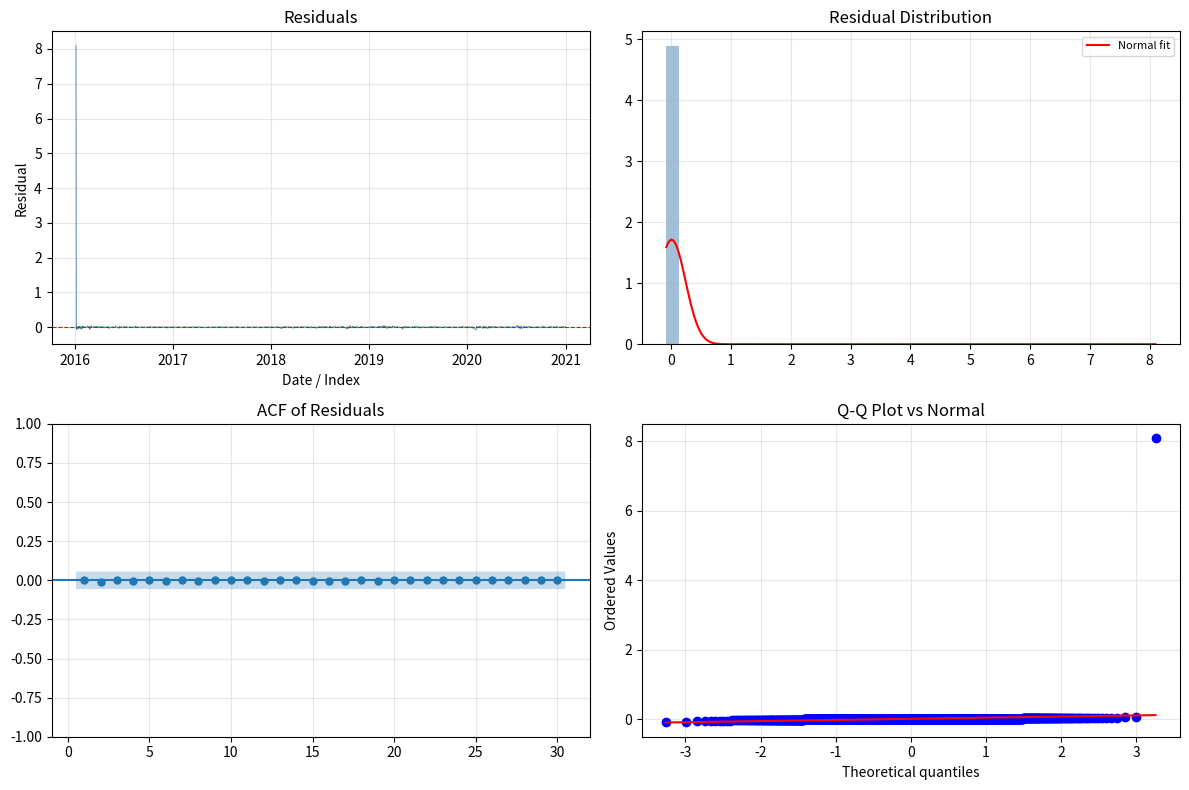

残差统计：


mean           0.006700
std            0.232416
skew          34.712777
kurtosis    1205.988300
Name: residual_stats, dtype: float64

In [7]:
diag = residual_diagnostics(
    result,
    lags=20,
    save_path=FIGURES / 'arima_residual_diagnostics.png'
)
plt.show()

print('残差统计：')
display(diag['summary_stats'])

In [8]:
lb = diag['ljung_box']
print('Ljung-Box 检验（残差）——前 5 个滞后：')
display(lb.head(5))
if (lb['lb_pvalue'] > 0.05).all():
    print('✓ 所有滞后 p > 0.05，残差近似白噪声')
else:
    print('✗ 存在显著自相关，考虑调整模型阶次')

Ljung-Box 检验（残差）——前 5 个滞后：


,lb_stat,lb_pvalue
1,0.009315,0.923111
2,0.105033,0.948838
3,0.109263,0.990703
4,0.158565,0.997018
5,0.158692,0.999496


✓ 所有滞后 p > 0.05，残差近似白噪声


## 5. 样本内拟合

将模型拟合值与训练集真实值对比，直观评估模型在样本内的拟合质量。

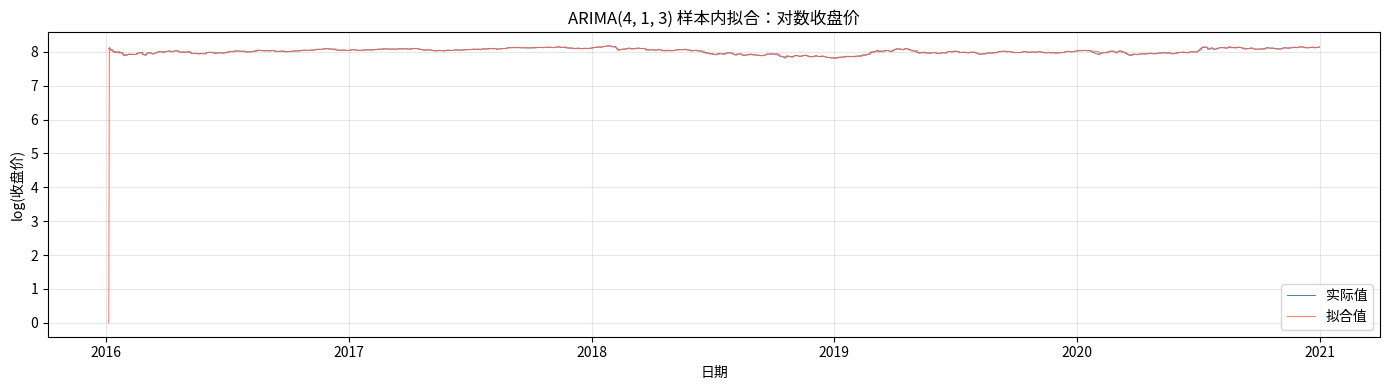

In [9]:
fitted = result.fittedvalues

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(series_train.index, series_train.values, linewidth=0.7,
        color='steelblue', label='实际值')
ax.plot(fitted.index, fitted.values, linewidth=0.8,
        color='tomato', alpha=0.8, label='拟合值')
ax.set_title(f'ARIMA{best_order} 样本内拟合：对数收盘价')
ax.set_xlabel('日期')
ax.set_ylabel('log(收盘价)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES / 'arima_insample_fit.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 样本外预测

加载测试集（2024-07-01 ~ 2024-12-31），生成对应步数的样本外预测，
并绘制预测值 vs 实际值的对比图（含 95% 置信区间）。

In [10]:
raw_test = load_test()
df_test = preprocess(raw_test)
print(f'测试集: {df_test.index.min().date()} ~ {df_test.index.max().date()}, {len(df_test)} 条')

测试集: 2021-01-05 ~ 2025-12-31, 1211 条


In [ ]:
series_test = df_test['log_close']
rolling_df, _ = rolling_forecast_arima(
    train_data=series_train,
    test_data=series_test,
    order=best_order,
    alpha=0.05,
)
fc_df = rolling_df[['forecast', 'lower_ci', 'upper_ci']]
fc_df.head()

/data/study/sh_arima_garch/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/data/study/sh_arima_garch/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/data/study/sh_arima_garch/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/data/study/sh_arima_garch/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
 

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

# 显示训练集最后 120 天作为背景
train_tail = series_train.tail(120)
ax.plot(train_tail.index, train_tail.values, color='steelblue',
        linewidth=0.8, label='训练集（最后 120 天）')

# 测试集实际值
actual_log = df_test['log_close']
ax.plot(actual_log.index, actual_log.values, color='black',
        linewidth=1.0, label='测试集实际值')

# 预测值与置信区间
ax.plot(fc_df.index, fc_df['forecast'], color='tomato',
        linewidth=1.0, linestyle='--', label='预测值')
ax.fill_between(fc_df.index, fc_df['lower_ci'], fc_df['upper_ci'],
                alpha=0.2, color='tomato', label='95% 置信区间')

ax.set_title(f'ARIMA{best_order} 样本外预测 vs 实际值')
ax.set_xlabel('日期')
ax.set_ylabel('log(收盘价)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES / 'arima_forecast_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 评估指标

在测试集上计算 MAE、RMSE 和 MAPE，评估预测精度。
注意：指标基于**对数收盘价**空间计算。

In [ ]:
actual = df_test['log_close'].values
predicted = fc_df['forecast'].values

mae = np.mean(np.abs(actual - predicted))
rmse = np.sqrt(np.mean((actual - predicted) ** 2))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

metrics = pd.DataFrame(
    {'MAE': [mae], 'RMSE': [rmse], 'MAPE (%)': [mape]},
    index=[f'ARIMA{best_order}']
)
print('测试集评估指标（对数收盘价）：')
display(metrics)

## 8. 结论

- 通过 AIC 网格搜索，选出了最优 ARIMA 阶次，并验证残差近似白噪声。
- 样本内拟合良好，但样本外预测随预测步数增大而置信区间急剧扩大，
  反映出金融时间序列长期预测的固有不确定性。
- **局限性**：ARIMA 假设线性关系且方差恒定，无法刻画收益率的波动率聚集现象，
  后续将在 Notebook 3 中使用 GARCH 模型进行补充建模。